# Exploratory Data Analysis (EDA) – Brazilian E-Commerce Dataset

Objective:
To analyze customer behavior, sales trends, payment preferences, seller performance, and delivery impact on customer satisfaction using the cleaned Brazilian e-commerce dataset.

Tools Used:
Python, Pandas, Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_customers.csv")
geo = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_geo.csv")
items = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_items.csv")
payments = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_payments.csv")
reviews = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_reviews.csv")
orders = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_orders.csv")
products = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_products.csv")
sellers = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_sellers.csv")
translation = pd.read_csv("C:/Users/bhakt/project/Brazilian e-commerece/cleaned dataset/clean_translation.csv")

In [3]:
orders[["delivery_time","delivery_delay"]].dtypes

delivery_time     float64
delivery_delay    float64
dtype: object

In [4]:
orders["delivery_time"].unique()[:10]

array([ 8., 13.,  9.,  2., 16., nan, 18., 12.,  5.,  4.])

In [5]:
orders["delivery_time"].isna().sum()

np.int64(2965)

In [6]:
import numpy as np

np.isinf(orders["delivery_time"]).sum()

np.int64(0)

## Q. What percentage of orders are delivered, canceled, processing, shipped?

In [4]:
orders["order_status"].value_counts()
orders["order_status"].value_counts(normalize=True)*100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

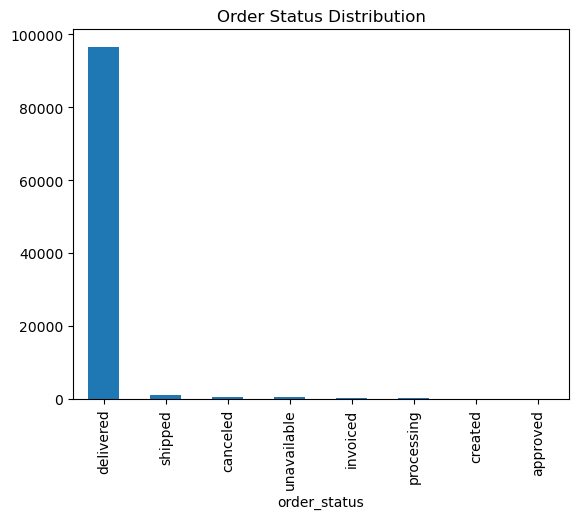

In [31]:
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.show()

## Observation

Most orders were successfully delivered, while only a small percentage were canceled or remained in intermediate processing stages.

## Business Insight

The high delivery rate indicates efficient order fulfillment, whereas canceled and unavailable orders represent opportunities for improving inventory and logistics management.

## Q. How do customers prefer to pay?

In [5]:
payments["payment_type"].value_counts()

payments["payment_type"].value_counts(normalize=True)*100

# (boleto = common Brazilian payment slip)

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

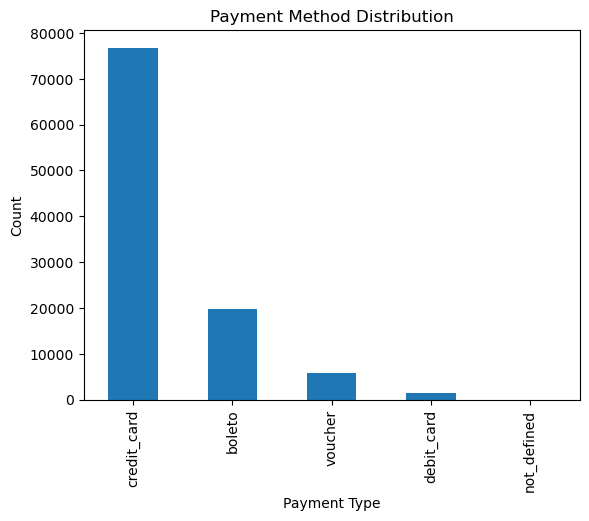

In [32]:
payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

## Observation 
A significant proportion of customers prefer credit card payments, indicating strong adoption of digital payment methods. This suggests that the platform should focus on optimizing credit card payment experience and promoting card-based offers to improve customer engagement.

## Business Insight

Since credit cards are the dominant payment method, offering installment plans and card-based promotions can improve customer engagement and increase sales.

## Q. How much revenue is generated overall?

In [6]:
payments["payment_value"].sum()

np.float64(16008872.120000001)

In [7]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

## Observation

- The dataset contains more than 100,000 payment transactions.
- The average transaction value is approximately 154 BRL.
- The maximum payment value is significantly higher than the average, indicating the presence of high-value purchases.

## Business Insight

Although most purchases are moderate in value, a small number of premium transactions contribute significantly to overall revenue.

## Q. Which states generate the most orders?

orders → has customer_id

customers → has customer_state

In [8]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="inner"
)

In [9]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,purchase_month,purchase_year,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,10,2017,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,7,2018,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,8,2018,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,11,2017,-13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,2,2018,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [10]:
orders_customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

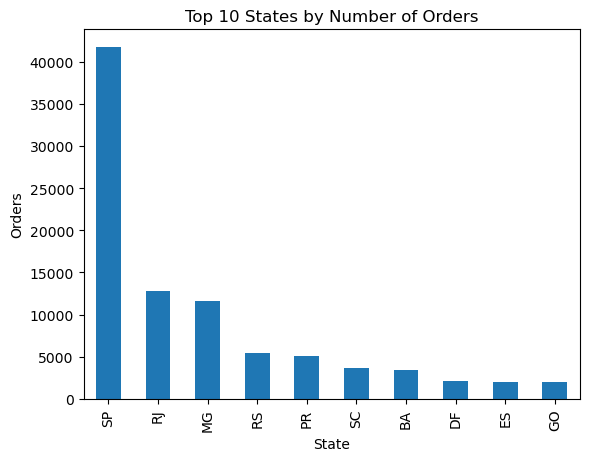

In [33]:
orders_customers["customer_state"]\
.value_counts()\
.head(10)\
.plot(kind="bar")

plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Orders")
plt.show()

## Observation

São Paulo contributes the highest number of customer orders among all Brazilian states.

## Business Insight :
The majority of orders originate from states such as Sao Paulo and Rio de Janeiro, indicating concentrated customer demand in Brazil’s urban regions. This suggests that focusing logistics infrastructure and targeted marketing in these regions could improve operational efficiency and customer reach.

## Q. Which product categories are sold the most?

order_items → has product_id,

products → has product_category_name,

translation → converts Portuguese category to English

In [12]:
items_products = items.merge(
    products,
    on="product_id",
    how="inner"
)

In [13]:
items_products = items_products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [14]:
items_products[
    "product_category_name_english"
].value_counts().head(10)

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

## Observation

Categories such as Bed Bath Table and Health Beauty have the highest sales volume.

## Buisness Insight :
Products belonging to categories such as bed_bath_table and health_beauty are purchased more frequently compared to other product categories.

## Q. Which product categories generate the most revenue?

In [15]:
items_products.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='object')

In [16]:
category_revenue = items_products.groupby(
    "product_category_name_english"
)["price"].sum()

In [17]:
category_revenue.sort_values(
    ascending=False
).head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

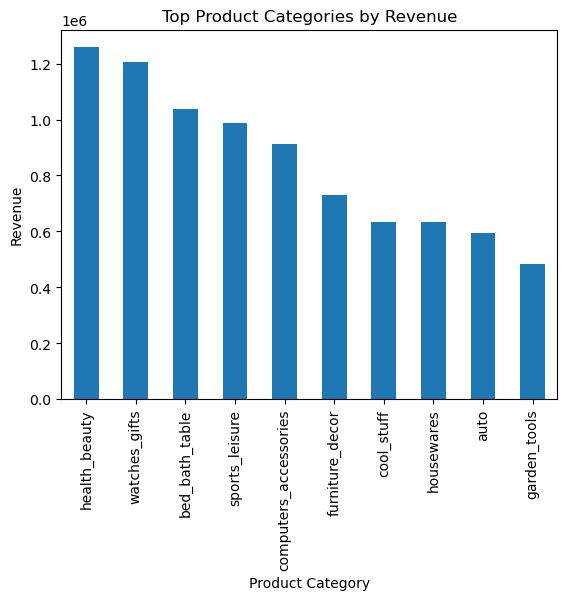

In [34]:
category_revenue.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

## Observation

Certain product categories contribute significantly more revenue than others despite differences in sales volume.

## Business Insight

High-revenue categories should receive priority in inventory planning, promotions, and supplier partnerships.

## Q. Which sellers generate the highest revenue?

In [18]:
seller_data = items.merge(
    sellers,
    on="seller_id",
    how="inner"
)

In [19]:
top_sellers= seller_data.groupby(
    "seller_id"
)["price"].sum()

In [20]:
top_sellers.sort_values(
    ascending=False
).head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

In [21]:
seller_data.groupby(
    "seller_state"
)["price"].sum().sort_values(
    ascending=False
).head(10)

seller_state
SP    8753396.21
PR    1261887.21
MG    1011564.74
RJ     843984.22
SC     632426.07
RS     378559.54
BA     285561.56
DF      97749.48
PE      91493.85
GO      66399.21
Name: price, dtype: float64

## Observation

A relatively small group of sellers contributes a substantial share of the platform's revenue.

## Business Insight

Identifying and supporting top-performing sellers can improve marketplace performance and customer satisfaction.

## Q. How long does delivery take on average?

In [22]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

In [23]:
orders["delivery_time"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# delivery date - purchase date = days taken

In [24]:
orders["delivery_time"].mean()

np.float64(12.094085575687217)

In [25]:
orders["delivery_time"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64

## Observation

The average delivery time is approximately 12 days, although delivery duration varies considerably between orders.

## Business Analysis t:
The average delivery time is approximately 12 days. While most deliveries are completed within a reasonable time frame, variations in delivery time may impact customer satisfaction and operational efficiency.

## Q. Do delayed deliveries lead to bad reviews?

In [26]:
delivery_reviews = orders.merge(
    reviews,
    on="order_id",
    how="inner"
)

In [27]:
delivery_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,purchase_month,purchase_year,delivery_delay,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,10,2017,-8.0,a54f0611adc9ed256b57ede6b6eb5114,4,No Comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,7,2018,-6.0,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,8,2018,-18.0,e73b67b67587f7644d5bd1a52deb1b01,5,No Comment,No Comment,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,11,2017,-13.0,359d03e676b3c069f62cadba8dd3f6e8,5,No Comment,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,2,2018,-10.0,e50934924e227544ba8246aeb3770dd4,5,No Comment,No Comment,2018-02-17 00:00:00,2018-02-18 13:02:51


In [28]:
delivery_reviews.groupby(
    "review_score"
)["delivery_time"].mean()

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_time, dtype: float64

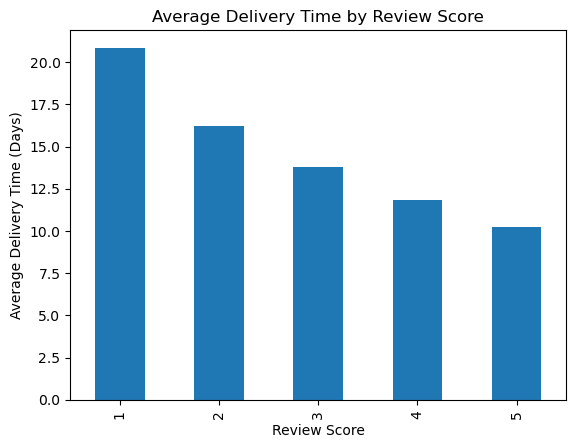

In [36]:
delivery_reviews.groupby(
    "review_score"
)["delivery_time"].mean().plot(
    kind="bar"
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")
plt.show()

## Observation

Customers who experienced longer delivery times consistently gave lower review scores.

## Buisness Insight 
Orders with lower review scores tend to have longer delivery times compared to highly rated orders. This suggests that delayed deliveries negatively impact customer satisfaction and may lead to poor customer experience.

# Correlation Analysis :
price  ↔ freight_value - If product price increases, does shipping cost also increase?

In [3]:
items[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


## Observation

Price and freight value show a positive relationship.

## Business Insight

Higher-priced products generally incur higher shipping costs because of factors such as weight, size, or insurance requirements.

# Distribution Analysis :
How is one variable distributed?

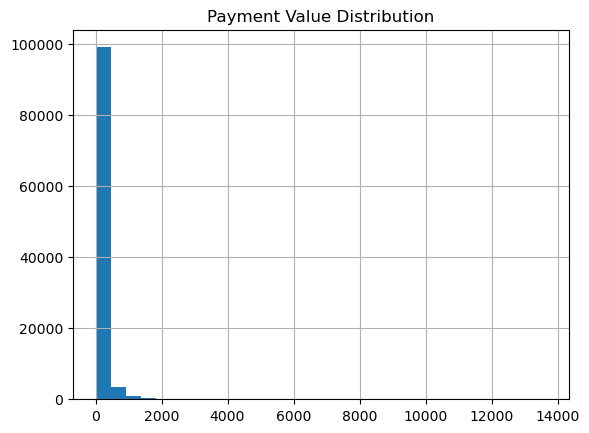

In [4]:
payments["payment_value"].hist(bins=30)
plt.title("Payment Value Distribution")
plt.show()

## Observation

The payment value distribution is right-skewed, with most transactions clustered at lower values and a small number of very expensive purchases.

## Insight 
Most customers make moderate purchases, while a small number contribute high transaction values.

# Boxplot Analysis :

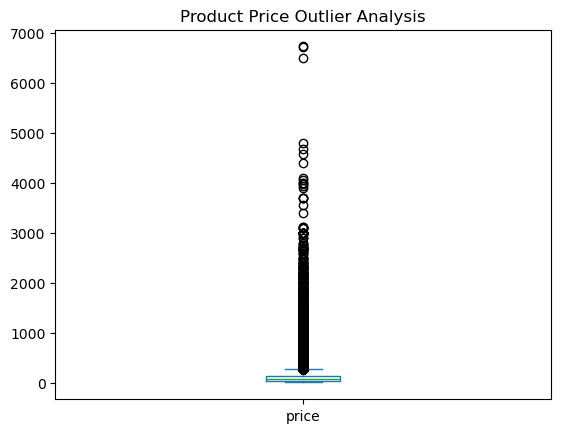

In [6]:
items["price"].plot(kind="box")
plt.title("Product Price Outlier Analysis")
plt.show()

## Observation

The boxplot reveals several high-value outliers in product prices.

## Business Insight

These outliers likely represent premium or luxury products rather than data entry errors and therefore were retained for analysis.

# Final Conclusions

## Key Findings

- Most customer orders were successfully delivered.
- Credit cards are the preferred payment method.
- São Paulo generates the highest number of orders.
- Bed Bath Table and Health Beauty are among the most popular product categories.
- A small number of sellers contribute a significant portion of total revenue.
- Delivery performance has a strong influence on customer satisfaction, with delayed deliveries receiving lower review scores.
- Premium products and high-value transactions contribute substantially to platform revenue.

## Overall Conclusion

The analysis provides valuable insights into customer purchasing behavior, payment preferences, seller performance, logistics efficiency, and product demand. These findings can support business decisions related to marketing strategies, inventory management, seller partnerships, and delivery optimization.